# Importing Necessary Packages

In [1]:
import os
import numpy as np
import nibabel as nib

# Z-Score Normalization of Images

In [3]:
def normalize(nii_image):
  image_arr = nii_image.get_fdata()
  return nib.Nifti1Image((image_arr - np.mean(image_arr)) / np.std(image_arr), affine=np.eye(4))

# Standard Histogram Equalization (HE) Algorithm

In [5]:
def global_histogram_equalization(nii_image):
  # Getting the Image as a 3D Array of values
  normalized_image = normalize(nii_image)
  normalized_image_arr = nii_image.get_fdata()
  # Computing the cumulative histogram of the normalized array
  histogram, bin_edges = np.histogram(normalized_image_arr, bins= 2 ** 16)
  cum_histogram = np.cumsum(histogram)
  # Computing the new intensity
  intensity = cum_histogram * (2 ** 16 - 1) / cum_histogram[-1]
  new_image_arr = np.interp(normalized_image_arr, bin_edges[:-1], intensity)
  return (new_image_arr - np.mean(new_image_arr)) / np.std(new_image_arr)

# Local Histogram Equalization (LHE) Algorithm

We will not adopt this Algorithm for many reasons:
* it causes Over-Enhancement of the image. look at the figure below.
* It takes two much time. we do HE for a (3x3x3) box whose anchor is the pixel we want to enhance.
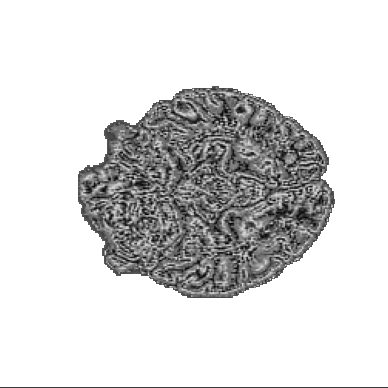

In [6]:
def pad(image_arr):
  return np.pad(image_arr, ((1, 1), (1, 1), (1, 1)), mode='edge')

In [7]:
# Do Histogram Equalization Locally to get the anchor pixel value
def do_he_on_region(image_region):
  histogram, bin_edges = np.histogram(image_region, bins=2**14)
  cum_histogram = np.cumsum(histogram)
  intensity = cum_histogram * (2 ** 14 - 1) / cum_histogram[-1]
  new_image_region = np.interp(image_region, bin_edges[:-1], intensity)
  return (new_image_region - np.mean(new_image_region)) / np.std(new_image_region)

In [7]:
def local_histogram_equalization(nii_image):
    # Getting the Image as a 3D Array of values
    image_arr = (nii_image.get_fdata()).astype(int)
    normalized_image_arr = (image_arr - np.mean(image_arr)) / np.std(image_arr)
    padded_image_arr = pad(normalized_image_arr)

    # Defining output array and enhancing the image pixels locally
    enhanced_arr = np.zeros(image_arr.shape)
    indices = np.indices((3, 3, 3)).reshape(3, -1).T

    for i in range(1, padded_image_arr.shape[0] - 1):
      for j in range(1, padded_image_arr.shape[1] - 1):
        for k in range(1, padded_image_arr.shape[2] - 1):
          # Get the 3x3x3 region using advanced indexing
          region_indices = indices + np.array([i, j, k]) - 1
          region = padded_image_arr[region_indices[:, 0], region_indices[:, 1], region_indices[:, 2]]
          enhanced_arr[i - 1, j - 1, k - 1] = do_he_on_region(region)[13]
    return enhanced_arr